# NB02B — validación puente de la arquitectura modal de NB03

### Proyecto: Simulación de speckle óptico mediante PINN-SIREN

**Objetivo.** Verificar, antes del campo aleatorio de NB03, que su arquitectura modal PINN-SIREN puede reproducir soluciones complejas conocidas de la ecuación de Helmholtz 2D cartesiana.

Este notebook se ubica en la cadena:

$$\boxed{\mathrm{NB01}\rightarrow\mathrm{NB02}\rightarrow\mathrm{NB02B}\rightarrow\mathrm{NB03}}$$

NB02B **no es todavía una simulación de speckle**. Es un experimento controlado que permite atribuir un posible fallo a la arquitectura modal, y no a la aleatoriedad del campo inicial.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = CURRENT if (CURRENT / 'scripts').exists() else CURRENT.parent
SCRIPT = PROJECT_ROOT / 'scripts' / 'experiments' / 'nb02b_modal_analytic_validation.py'
RESULTS = PROJECT_ROOT / 'results' / 'nb02b_modal_bridge'
SUMMARY = RESULTS / 'summary.json'
BASIS_SCRIPT = PROJECT_ROOT / 'scripts' / 'experiments' / 'nb02b_modal_fundamental_basis_validation.py'
BASIS_RESULTS = PROJECT_ROOT / 'results' / 'nb02b_modal_basis'
BASIS_SUMMARY = BASIS_RESULTS / 'summary.json'

print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'Script reproducible: {SCRIPT}')
print(f'Resultados propagantes: {RESULTS}')
print(f'Resultados de la base fundamental: {BASIS_RESULTS}')

Raíz del proyecto: C:\roberto\Tesis_Maestria - codex
Script reproducible: C:\roberto\Tesis_Maestria - codex\scripts\experiments\nb02b_modal_analytic_validation.py
Resultados propagantes: C:\roberto\Tesis_Maestria - codex\results\nb02b_modal_bridge
Resultados de la base fundamental: C:\roberto\Tesis_Maestria - codex\results\nb02b_modal_basis


## 1. Problema físico controlado

En coordenadas cartesianas normalizadas $(\tilde x,\tilde z)$ se resuelve

$$\boxed{\frac{\partial^2E}{\partial\tilde x^2}+\frac{\partial^2E}{\partial\tilde z^2}+\tilde k^2E=0},\qquad \tilde k=2\pi.$$

La solución de referencia es una superposición finita de ondas planas:

$$\boxed{E_{\mathrm{ref}}(\tilde x,\tilde z)=\sum_m A_m e^{i(\tilde k_{x,m}\tilde x+\tilde k_{z,m}\tilde z)}}.$$

Para cada modo se impone la relación de dispersión

$$\tilde k_{x,m}^2+\tilde k_{z,m}^2=\tilde k^2,$$

por lo que cada término y su suma satisfacen exactamente Helmholtz. Al combinar varios modos aparecen interferencias y una intensidad no uniforme, pero seguimos conociendo la respuesta exacta.

## 2. Reducción modal y conexión con NB03

Se escribe

$$E(\tilde x,\tilde z)=\sum_m a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x}.$$

Al sustituir en Helmholtz, cada coeficiente satisface

$$\boxed{a_m''(\tilde z)+\tilde k_{z,m}^2a_m(\tilde z)=0}.$$

La condición de onda que avanza hacia $+z$, con la convención temporal $e^{-i\omega t}$, proporciona

$$a_m(0)=A_m,\qquad a_m'(0)=i\tilde k_{z,m}A_m.$$

Estas son las únicas cantidades exactas entregadas al modelo. La solución completa se reserva para validación.

## 3. Condición de Cauchy dura

La salida física se construye como

$$a_{m,\theta}(\tilde z)=A_m+\tilde z\,i\tilde k_{z,m}A_m+\tilde z^2N_{m,\theta}(\tilde z).$$

Así, para cualquier valor de los pesos de la red,

$$a_{m,\theta}(0)=A_m,\qquad a_{m,\theta}'(0)=i\tilde k_{z,m}A_m.$$

No es necesario penalizar estas condiciones en la función de pérdida: quedan satisfechas por construcción.

## 4. Arquitectura que se está poniendo a prueba

Se importa directamente la clase `ModalSiren` utilizada por NB03. De esta manera no se crea una imitación aproximada de la arquitectura.

| Elemento | Configuración validada de NB03 |
|---|---:|
| Entrada | $\tilde z$ |
| Capas ocultas | 4 |
| Neuronas por capa | 128 |
| $\omega_{0,\mathrm{primera}}$ | 1 |
| $\omega_{0,\mathrm{interna}}$ | 1 |
| Salidas | partes real e imaginaria de todos los modos |
| Etiquetas interiores | 0 |

> **Sobre $\omega_0$ de la primera capa.** El módulo `nb03_modal_pinn_siren` trae
> `FIRST_OMEGA = 30.0` como valor por defecto, que es el de Sitzmann para
> imágenes. **No es la configuración de NB03:** tanto NB03 como este notebook lo
> sobrescriben a $1$ mediante `NB03_MODAL_FIRST_OMEGA`, siguiendo la regla de
> NB01 $\omega_0\approx k/2\pi$. La entrada es $\tilde z\in[0,1]$ y cada
> coeficiente modal oscila menos de una vez en ese tramo, así que no hace falta
> más ancho de banda. En el barrido de NB03, $\omega_0=30$ degrada el error
> propagante unas 35 veces frente a $\omega_0=1$.
>
> $\omega_0$ **no vive en el `state_dict`**: se fija al construir `SineLayer`. Si
> se reconstruye la red con otro valor y se le cargan pesos entrenados, la
> función resultante es distinta y no hay ningún error visible.

In [2]:
# omega_0 se fija al construir SineLayer y NO vive en el state_dict, asi que
# hay que declararlo ANTES de importar el modulo. Mismo valor que usa NB03.
os.environ['NB03_MODAL_FIRST_OMEGA'] = '1'
os.environ['NB03_MODAL_HIDDEN_OMEGA'] = '1'

sys.path.insert(0, str(PROJECT_ROOT))
from scripts.experiments import nb03_modal_pinn_siren as nb03_arch

architecture = {
    'capas_ocultas': nb03_arch.NUM_LAYERS,
    'neuronas_por_capa': nb03_arch.HIDDEN_DIM,
    'omega_primera': nb03_arch.FIRST_OMEGA,
    'omega_interna': nb03_arch.HIDDEN_OMEGA,
}
pd.Series(architecture, name='valor').to_frame()

,valor
capas_ocultas,4.0
neuronas_por_capa,128.0
omega_primera,1.0
omega_interna,1.0


## 5. Validación de la base modal fundamental

Antes de estudiar una onda saliente o una superposición de muchos modos, se valida la solución general de cada EDO modal:

$$\frac{d^2a_m}{d\tilde z^2}+\tilde k_{z,m}^2a_m=0,$$

$$a_m(\tilde z)=C_m\cos(\tilde k_{z,m}\tilde z)+D_m\sin(\tilde k_{z,m}\tilde z).$$

Se elige un modo propagante que satisface exactamente la relación de dispersión $\tilde k_x^2+\tilde k_z^2=\tilde k^2$, con $\tilde k=2\pi$, $\tilde k_x=0.6\tilde k$ y $\tilde k_z=0.8\tilde k$. Se prueban tres problemas de Cauchy independientes:

| Caso | $C_m$ | $D_m$ | Condiciones impuestas exactamente |
|---|---:|---:|---|
| Base coseno | $1$ | $0$ | $a_m(0)=1$, $a_m'(0)=0$ |
| Base seno | $0$ | $1$ | $a_m(0)=0$, $a_m'(0)=\tilde k_z$ |
| Combinación compleja | $0.6+0.2i$ | $-0.3+0.7i$ | $a_m(0)=C_m$, $a_m'(0)=\tilde k_zD_m$ |

La red mantiene la condición de Cauchy dura $a_{m,\theta}(\tilde z)=a_m(0)+\tilde z a_m'(0)+\tilde z^2N_\theta(\tilde z)$. Durante el entrenamiento no se proporcionan valores analíticos interiores. La referencia cerrada se utiliza únicamente después del entrenamiento para calcular los errores.

In [3]:
# Cambiar a True únicamente si se desea repetir esta validación desde cero.
FORCE_RETRAIN_BASIS = False

if FORCE_RETRAIN_BASIS or not BASIS_SUMMARY.exists():
    subprocess.run(
        [sys.executable, '-u', str(BASIS_SCRIPT)],
        cwd=PROJECT_ROOT, env=os.environ.copy(), check=True,
    )

with BASIS_SUMMARY.open(encoding='utf-8') as stream:
    basis_report = json.load(stream)

assert basis_report['training_uses_interior_labels'] is False
assert basis_report['architecture']['first_omega'] == nb03_arch.FIRST_OMEGA

basis_rows = []
for case in basis_report['cases']:
    metric = case['metrics']
    basis_rows.append({
        'caso': case['label'],
        'L2 coeficiente (%)': 100 * metric['coefficient_relative_l2'],
        'L2 campo final (%)': 100 * metric['target_complex_relative_l2'],
        'coherencia global': metric['global_complex_coherence'],
        'residuo modal': metric['helmholtz_modal_residual_normalized_rmse'],
        'error Cauchy a(0)': metric['hard_cauchy_coefficient_abs_error'],
        "error Cauchy a'(0)": metric['hard_cauchy_derivative_abs_error'],
        'tiempo (s)': case['training_seconds'],
        'aceptado': case['acceptance']['accepted'],
    })

basis_table = pd.DataFrame(basis_rows).set_index('caso')
basis_table.round(8)

,L2 coeficiente (%),L2 campo final (%),coherencia global,residuo modal,error Cauchy a(0),error Cauchy a'(0),tiempo (s),aceptado
caso,,,,,,,,
Base coseno,0.004965,0.004704,1.0,0.001587,0.0,0.0,41.208687,True
Base seno,0.007914,0.003062,1.0,0.003311,0.0,0.0,52.154969,True
Combinación compleja general,0.008287,0.007892,1.0,0.001476,0.0,0.0,76.390301,True


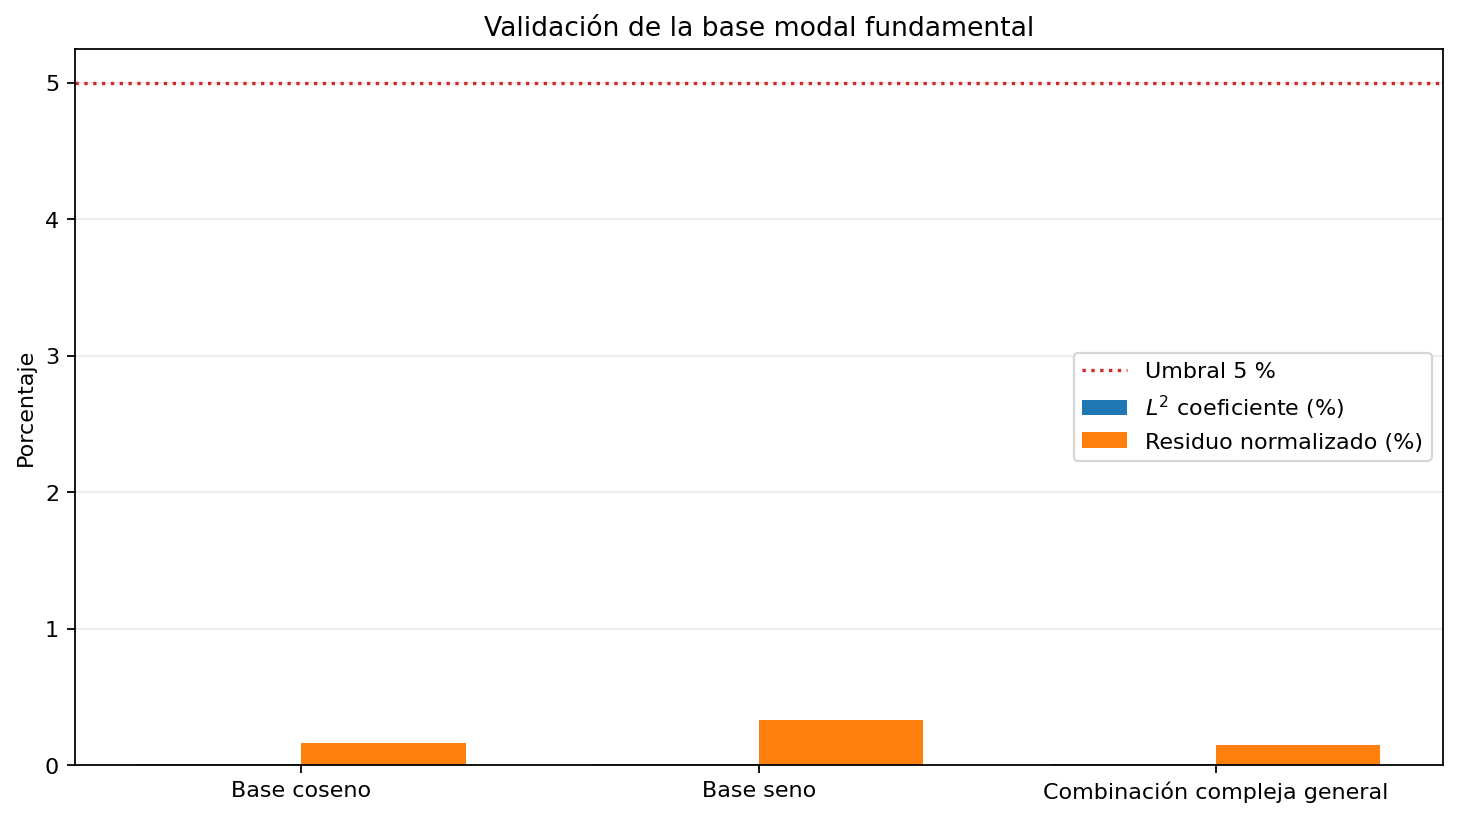

Base coseno, seno y combinación general aceptadas: True


In [4]:
display(Image(filename=str(BASIS_RESULTS / 'figures' / 'summary_basis.png')))
print(f'Base coseno, seno y combinación general aceptadas: {basis_report["all_cases_accepted"]}')

### Interpretación física y matemática

Los tres casos fueron aceptados. El error $L^2$ del coeficiente fue $0.004965\%$ para la base coseno, $0.007914\%$ para la base seno y $0.008287\%$ para la combinación compleja general. Las coherencias globales fueron mayores que $0.99999999$. Los errores de las dos condiciones de Cauchy fueron exactamente cero dentro de la precisión registrada.

Esto comprueba que la arquitectura representa las dos soluciones linealmente independientes de la EDO modal. Por linealidad, también reproduce una combinación compleja general. La onda saliente $A_m e^{i\tilde k_{z,m}\tilde z}$ estudiada a continuación es un caso particular obtenido con $C_m=A_m$ y $D_m=iA_m$.

## 6. Aplicación propagante y escalera de dificultad

Se evalúan tres casos manteniendo la misma red:

| Caso | Interpretación |
|---:|---|
| 1 modo | Verifica una onda plana compleja |
| 5 modos | Verifica interferencia multimodal sencilla |
| 41 modos | Iguala la cantidad de modos complejos del NB03 actual |

El entrenamiento minimiza únicamente el residuo modal. La referencia analítica no participa en la optimización.

In [5]:
# Cambiar a True para repetir desde cero el entrenamiento completo.
FORCE_RETRAIN = False

def run_stage(**overrides):
    environment = os.environ.copy()
    environment.update({key: str(value) for key, value in overrides.items()})
    subprocess.run(
        [sys.executable, '-u', str(SCRIPT)], cwd=PROJECT_ROOT,
        env=environment, check=True,
    )

if FORCE_RETRAIN or not SUMMARY.exists():
    common = {
        'NB02B_CASE_COUNTS': '1,5,41',
        'NB02B_N_Z_EVAL': 301, 'NB02B_N_X_EVAL': 512,
        # omega_0 de la primera capa: el default del modulo es 30 (valor de
        # Sitzmann para imagenes). NB03 lo sobrescribe a 1 y aqui se hace igual,
        # para que el puente mida la configuracion que NB03 realmente usa.
        'NB03_MODAL_FIRST_OMEGA': '1',
        'NB03_MODAL_HIDDEN_OMEGA': '1',
    }
    # Etapa 1: exploración Adam desde pesos nuevos.
    run_stage(**common, NB02B_EPOCHS=2500, NB02B_N_Z_TRAIN=256,
              NB02B_LR='2e-4', NB02B_OPTIMIZER='adam',
              NB02B_RESUME_EXISTING=0)
    # Etapa 2: continuación Adam de baja tasa.
    run_stage(**common, NB02B_EPOCHS=6000, NB02B_N_Z_TRAIN=256,
              NB02B_LR='5e-5', NB02B_OPTIMIZER='adam',
              NB02B_RESUME_EXISTING=1)
    # Etapa 3: refinamiento físico L-BFGS con colocación fija.
    run_stage(**common, NB02B_EPOCHS=80, NB02B_N_Z_TRAIN=512,
              NB02B_OPTIMIZER='lbfgs', NB02B_LBFGS_INNER_ITER=20,
              NB02B_RESUME_EXISTING=1)
else:
    print('Se reutiliza la ejecución registrada. Use FORCE_RETRAIN=True para repetirla.')

Se reutiliza la ejecución registrada. Use FORCE_RETRAIN=True para repetirla.


## 7. Métricas independientes

La exactitud del campo complejo se mide con

$$L_E^2=\frac{\lVert E_\theta-E_{\mathrm{ref}}\rVert_2}{\lVert E_{\mathrm{ref}}\rVert_2}.$$

También se reportan coherencia compleja, intensidad, fase, residuo de Helmholtz y errores de Cauchy. Los criterios de aceptación del puente son:

$$L^2_{E,\mathrm{global}}<5\%,\qquad L^2_{E,\tilde z=1}<5\%,$$

$$\mathrm{coherencia}_{\tilde z=1}>0.90,\qquad \mathrm{RMSE}(R_E)<0.05.$$

In [6]:
with SUMMARY.open(encoding='utf-8') as stream:
    report = json.load(stream)

# La corrida y este notebook deben coincidir en omega_0. Si no, las metricas de
# abajo describen una red distinta de la que la tabla anterior declara.
assert report['architecture']['first_omega'] == nb03_arch.FIRST_OMEGA, (
    f"omega_0 del notebook ({nb03_arch.FIRST_OMEGA}) != de la corrida "
    f"({report['architecture']['first_omega']}). Borre results/nb02b_modal_bridge "
    f"y vuelva a ejecutar."
)

rows = []
for case in report['cases']:
    metric = case['metrics']
    rows.append({
        'modos': case['n_complex_modes'],
        'pasos acumulados': case['cumulative_recorded_epochs'],
        'L2 global (%)': 100 * metric['global_complex_relative_l2'],
        'L2 en z=1 (%)': 100 * metric['target_complex_relative_l2'],
        'coherencia z=1': metric['target_complex_coherence'],
        'residuo Helmholtz': metric['helmholtz_field_residual_normalized_rmse'],
        'Cauchy campo': metric['hard_cauchy_coefficient_rmse'],
        'Cauchy derivada': metric['hard_cauchy_derivative_rmse'],
        'tiempo (s)': case['training_seconds'],
        'aceptado': case['acceptance']['accepted'],
    })

results_table = pd.DataFrame(rows).set_index('modos')
results_table.round({
    'L2 global (%)': 4,
    'L2 en z=1 (%)': 4,
    'coherencia z=1': 6,
    'residuo Helmholtz': 6,
    'Cauchy campo': 9,
    'Cauchy derivada': 9,
    'tiempo (s)': 1,
})

,pasos acumulados,L2 global (%),L2 en z=1 (%),coherencia z=1,residuo Helmholtz,Cauchy campo,Cauchy derivada,tiempo (s),aceptado
modos,,,,,,,,,
1,8580,0.0149,0.0030,1.0,0.001736,0.000000e+00,1.750000e-07,29.8,True
5,8580,0.0112,0.0070,1.0,0.001553,9.000000e-09,6.700000e-08,39.6,True
41,8580,0.0078,0.0073,1.0,0.001321,4.000000e-09,2.500000e-08,57.0,True


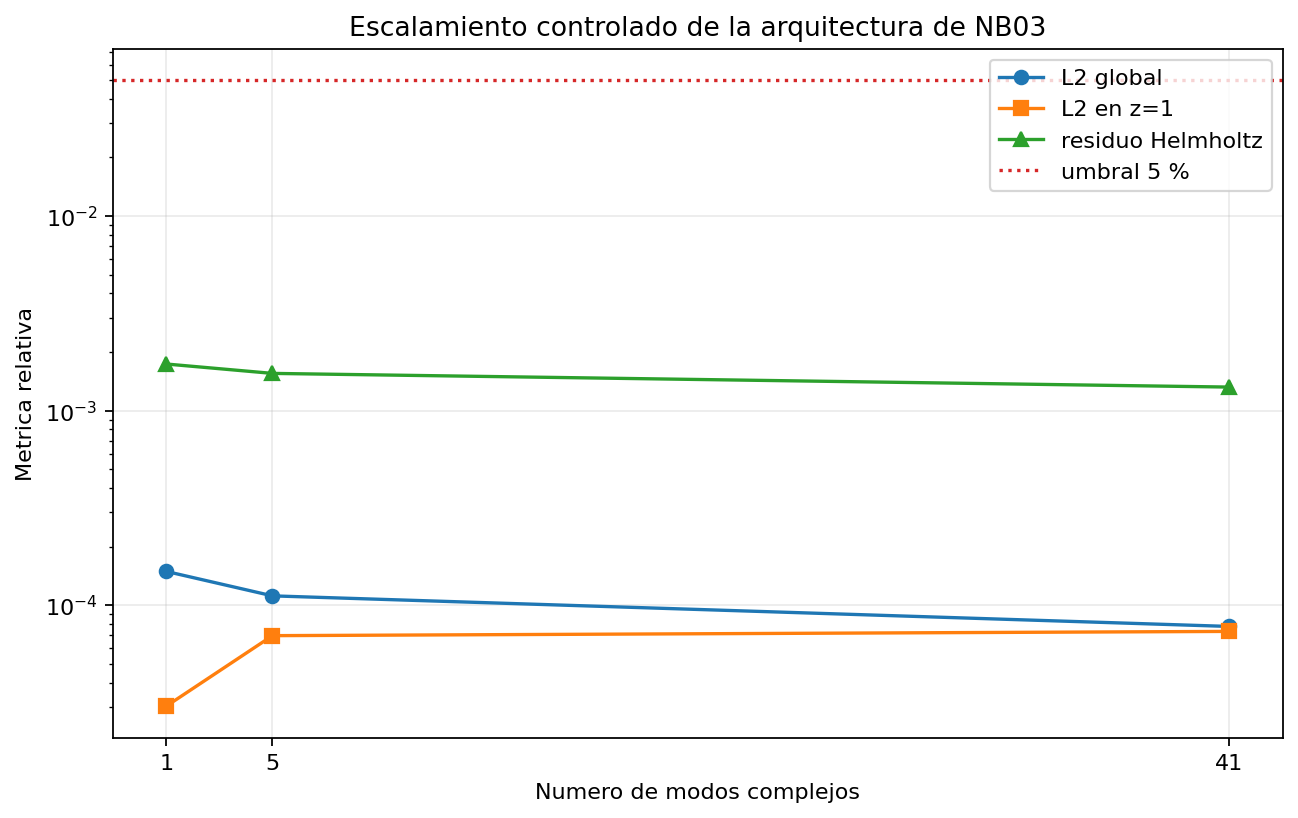

In [7]:
display(Image(filename=str(RESULTS / 'figures' / 'summary_modes.png')))

## 8. Inspección física por número de modos

Cada figura contiene: intensidad analítica y predicha en $\tilde z=1$; error complejo a lo largo de la propagación; mapa $I(\tilde x,\tilde z)$; y evolución de la pérdida física.

Caso: 1 modo(s)


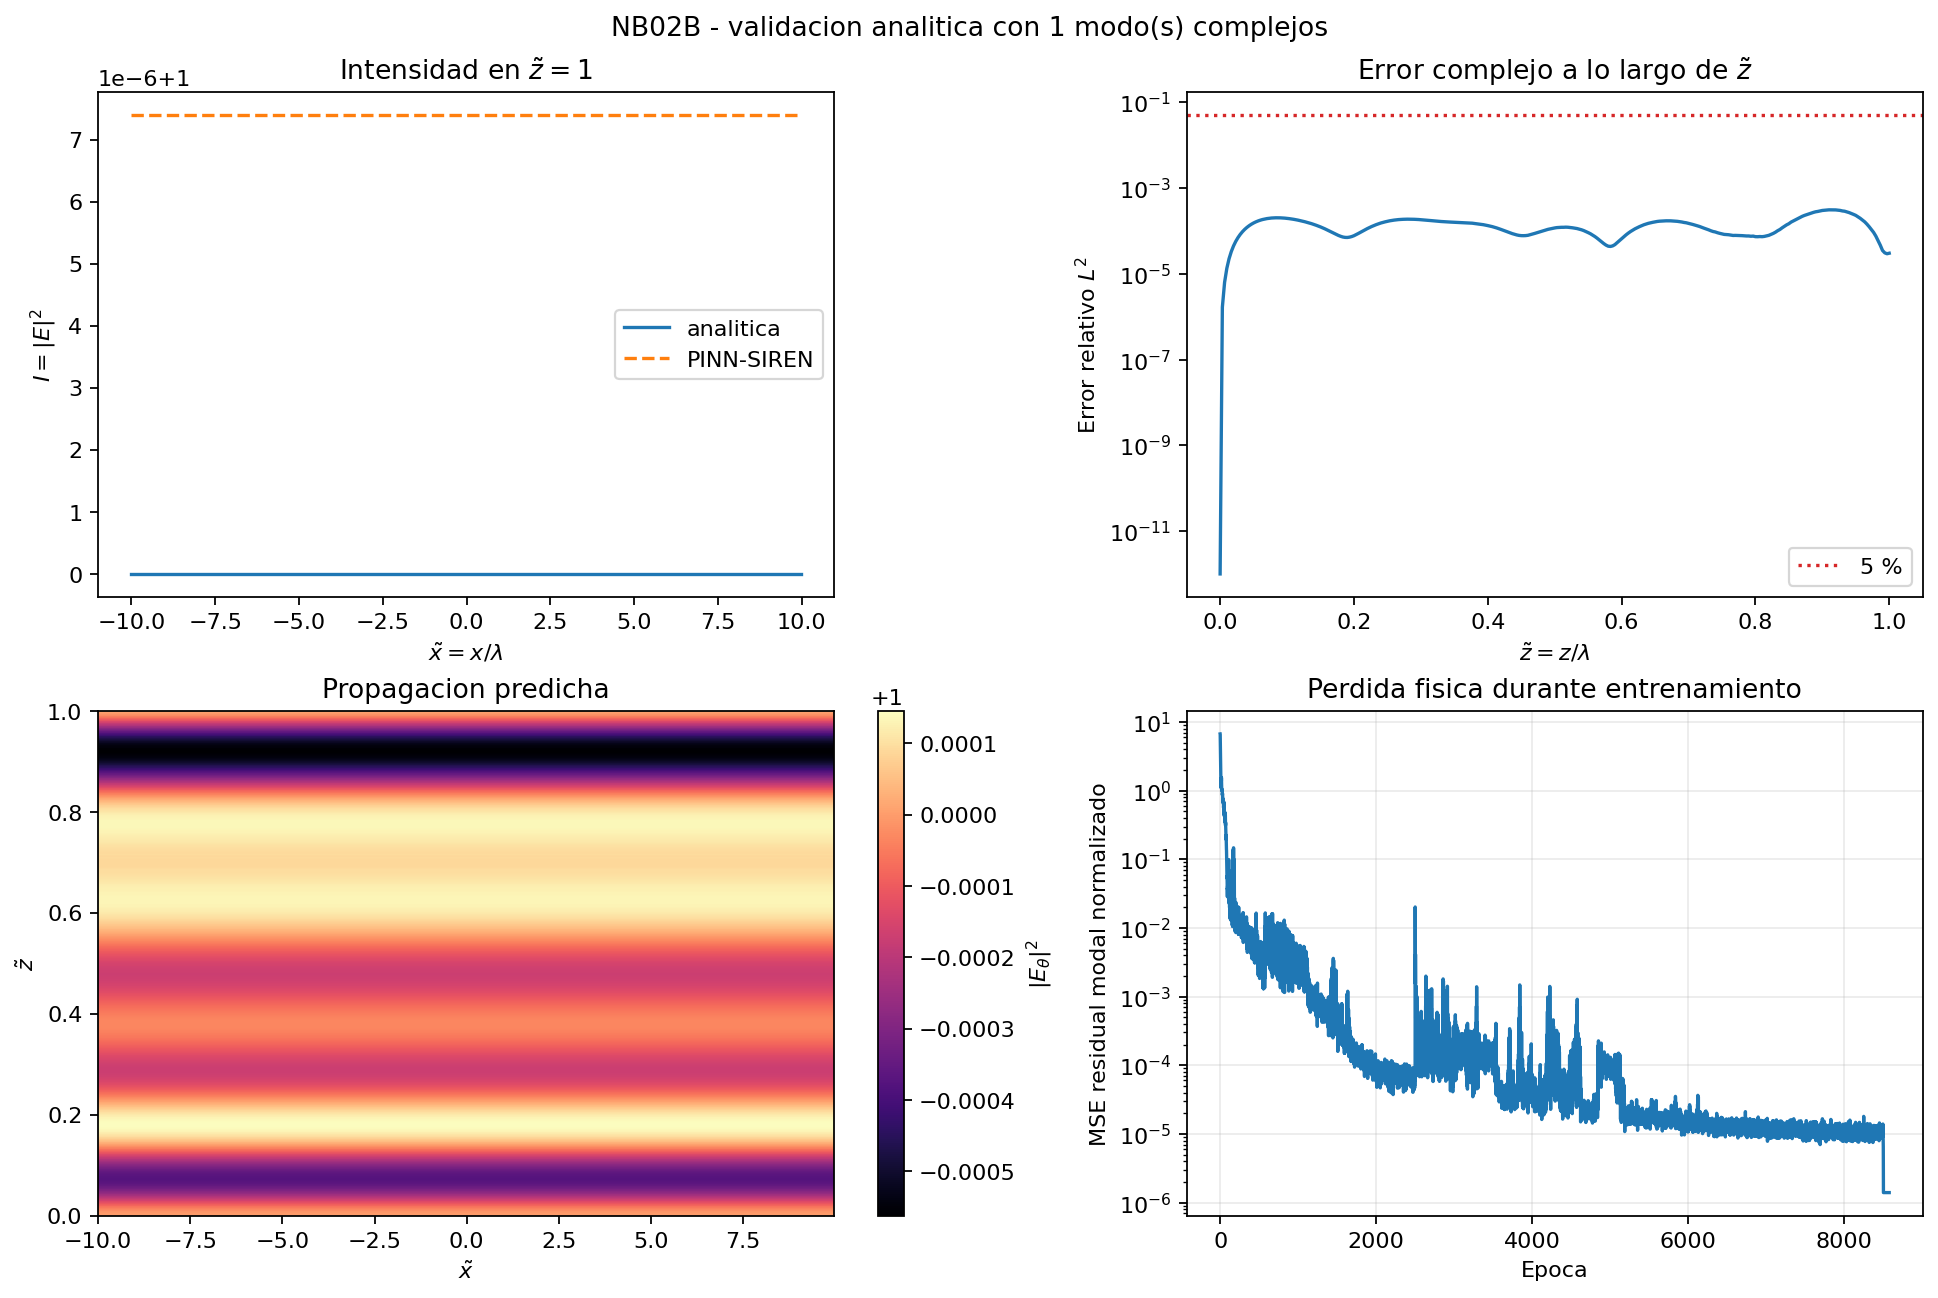

Caso: 5 modo(s)


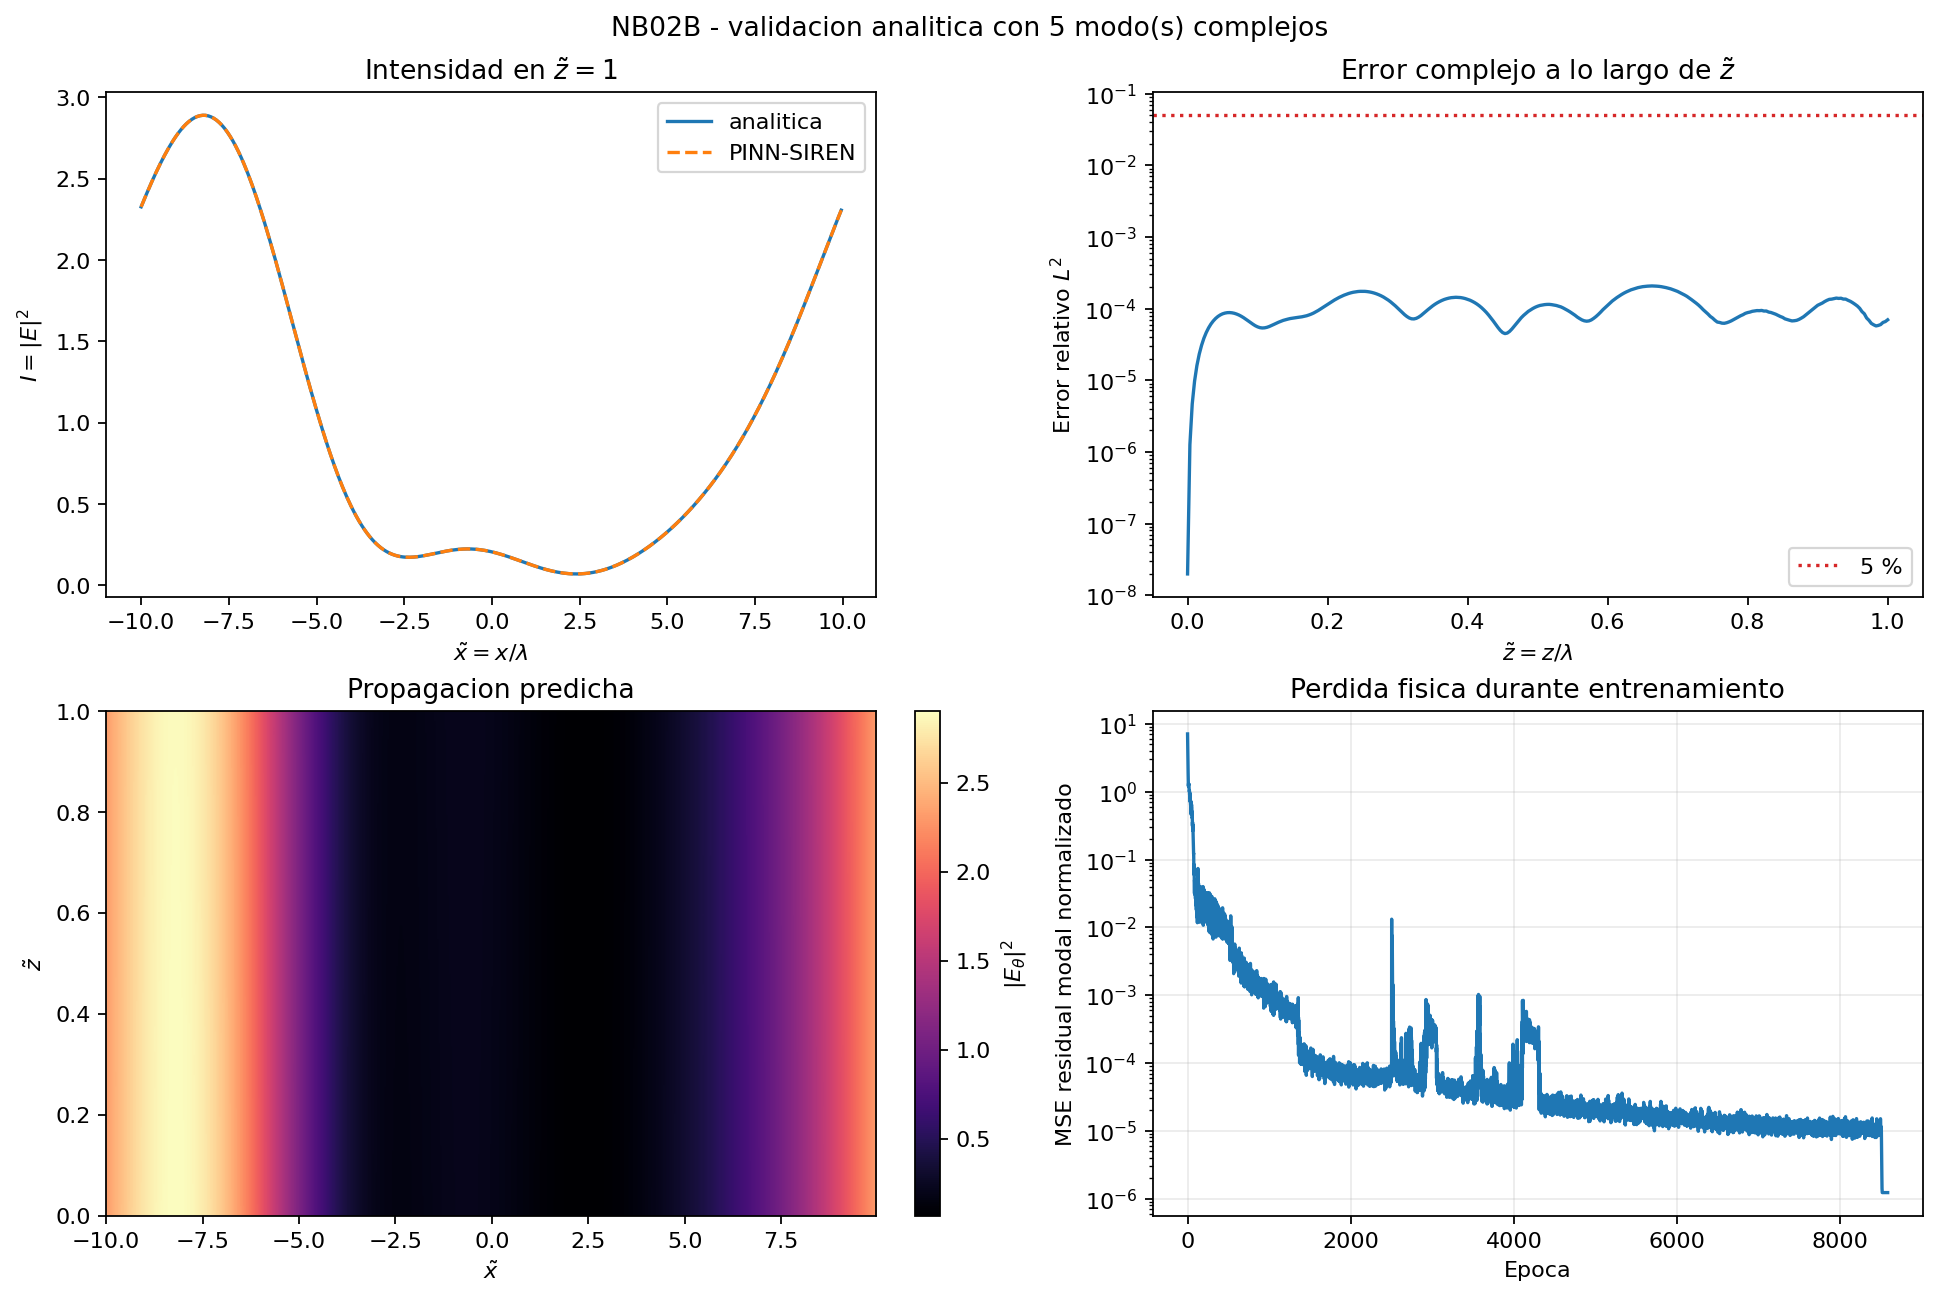

Caso: 41 modo(s)


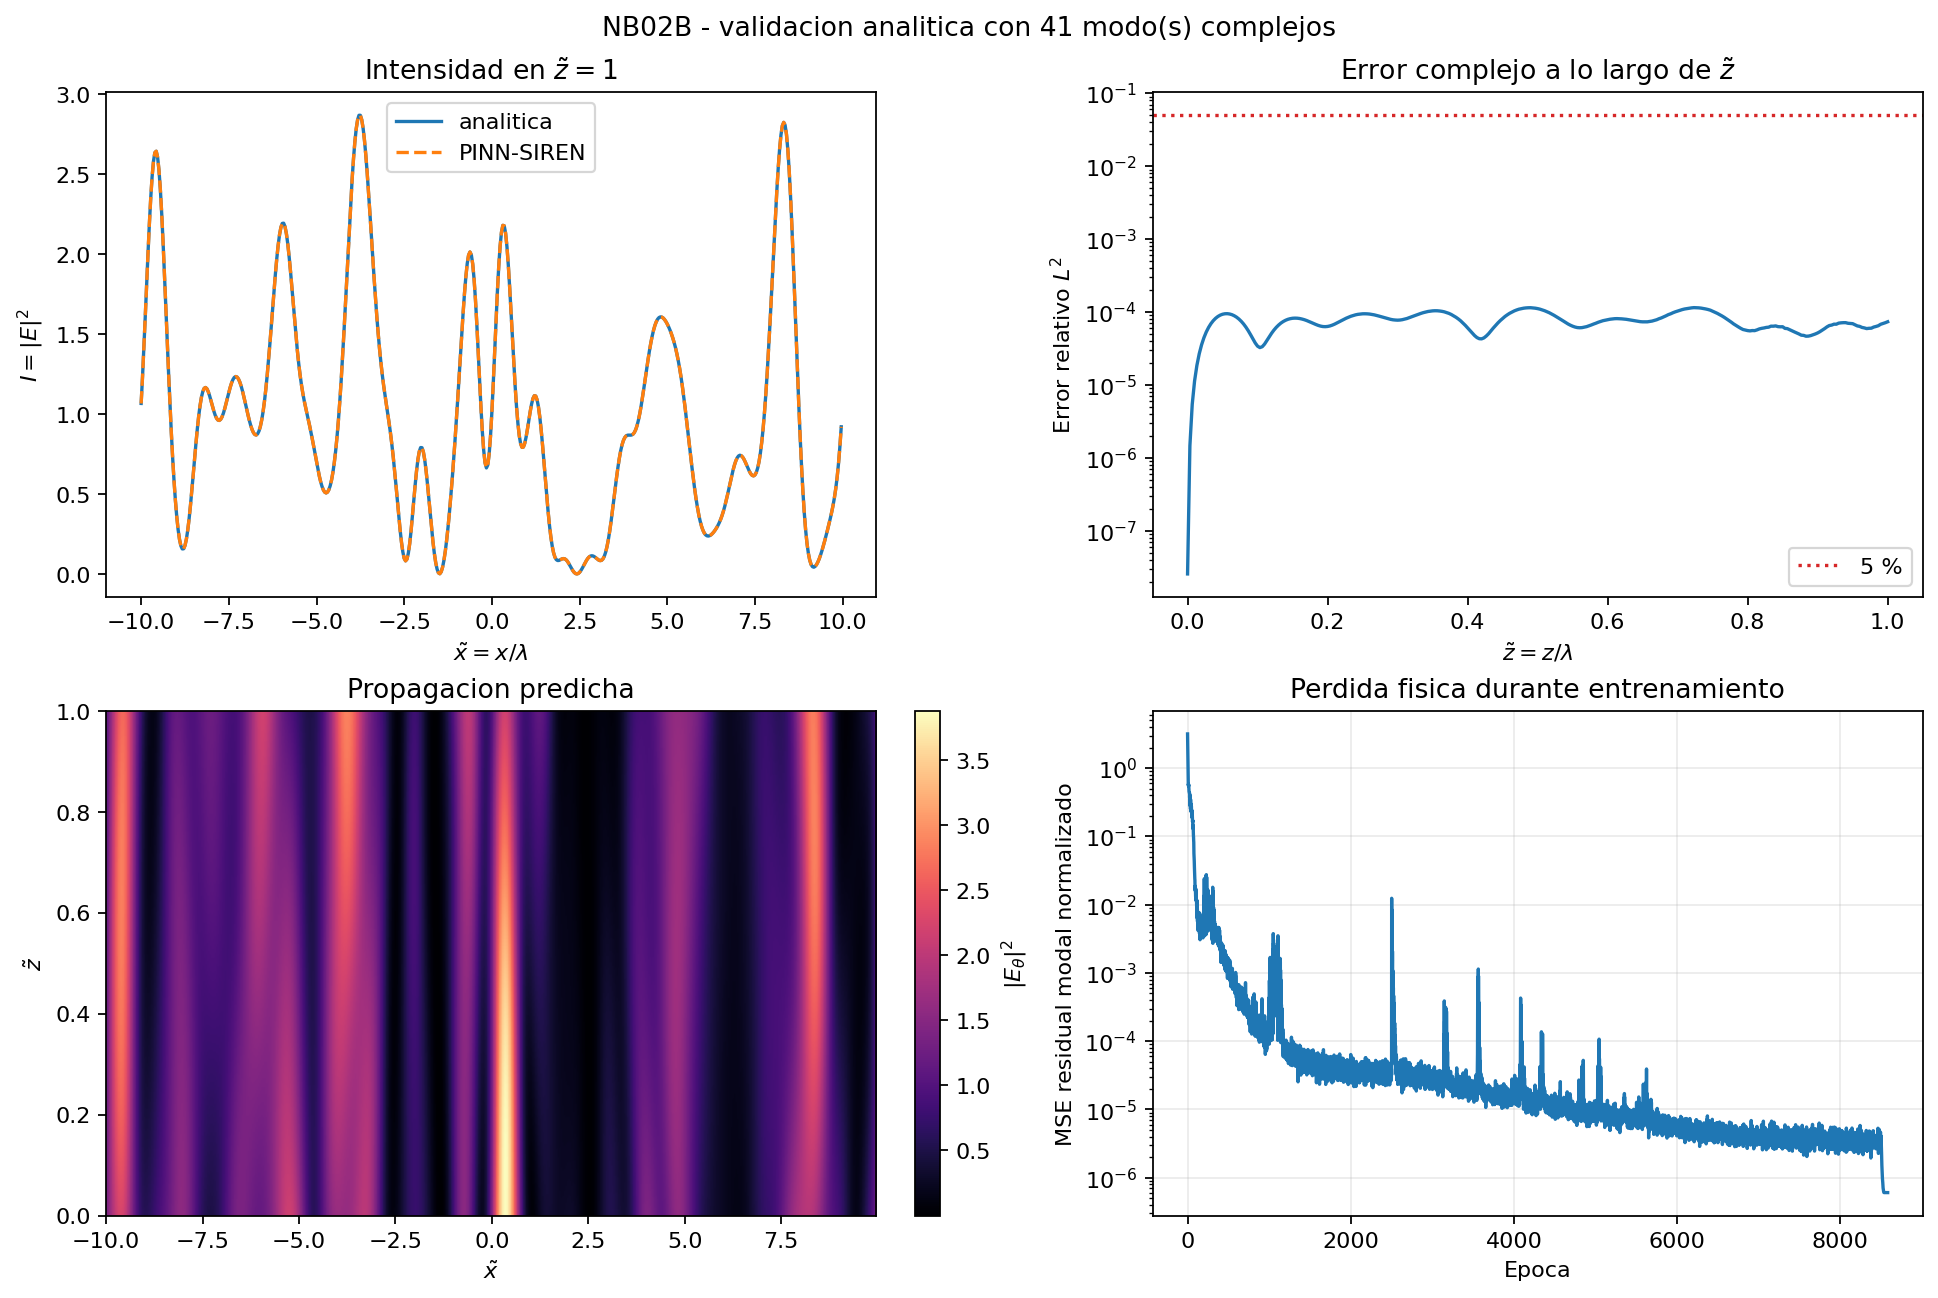

In [8]:
for count in (1, 5, 41):
    print(f'Caso: {count} modo(s)')
    display(Image(filename=str(RESULTS / 'figures' / f'case_{count:02d}_modes.png')))

## 9. Cómo interpretar el resultado

- Si pasan 1, 5 y 41 modos, la arquitectura modal está controlada y puede trasladarse con mayor confianza al campo aleatorio de NB03.
- Si pasa 1 modo pero falla 5, aparece una dificultad al representar simultáneamente frecuencias diferentes.
- Si pasan 1 y 5 pero falla 41, el cuello de botella está asociado a escala, capacidad o acondicionamiento multimodal.
- Si falla incluso 1 modo, debe revisarse la condición de Cauchy, la normalización del residuo, $\omega_0$ o el optimizador antes de tocar el speckle.

Esta lógica evita atribuir automáticamente al fenómeno aleatorio un error que podría proceder de la red.

In [9]:
passed = [
    case['n_complex_modes']
    for case in report['cases']
    if case['acceptance']['accepted']
]
failed = [
    case['n_complex_modes']
    for case in report['cases']
    if not case['acceptance']['accepted']
]
print(f'Casos aprobados: {passed}')
print(f'Casos no aprobados: {failed}')
print(f'Validación completa del puente: {report["all_cases_accepted"]}')

Casos aprobados: [1, 5, 41]
Casos no aprobados: []
Validación completa del puente: True


## 10. Alcance y siguiente decisión

NB02 continúa validando una PINN directa sobre $(\tilde x,\tilde y)$. NB02B valida la representación modal exacta empleada después sobre $(\tilde x,\tilde z)$. Son pruebas complementarias, no duplicadas.

El intervalo $0\leq\tilde z\leq1$ se utiliza únicamente como dominio normalizado canónico para comprobar la solución modal. NB02B no estudia el alcance en distancia ni valida todavía un campo speckle. Los pesos entrenados aquí tampoco sustituyen los de NB03 porque las amplitudes modales del speckle son diferentes. La validación física por distancia comienza en NB03 y continúa en NB03B.